# 04 – Clustering Attrition Association Rules

## Mục tiêu
- Chỉ tập trung vào các luật kết hợp **liên quan đến Attrition = Leave**
- Biến các luật thành vector đặc trưng
- Phân cụm các luật để phát hiện **nhóm nguyên nhân nghỉ việc chính**
- Diễn giải ý nghĩa từng cụm phục vụ phân tích HR

## Ý tưởng chính
- Mỗi luật kết hợp được xem như một quan sát
- Antecedents của luật = đặc trưng (0/1)
- Trọng số đặc trưng = lift × confidence
- Dùng KMeans để phân cụm luật

### PARAMETERS

In [1]:
import os
import sys

# Xác định project root (chạy được cả notebook + papermill)
current_dir = os.getcwd()

if current_dir.endswith("notebooks"):
    project_root = os.path.abspath("..")
else:
    project_root = current_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root:", project_root)

Project root: D:\KHMT_16-01\Data Mining\HR_Attrition


In [2]:
# Input
RULES_INPUT_PATH = "../data/processed/rules_apriori_leave_top100.csv"

# Feature engineering
WEIGHTING = "lift_x_conf"     # none | lift | confidence | lift_x_conf

# Clustering
K_MIN = 2
K_MAX = 8
RANDOM_STATE = 42

# Output
OUTPUT_CLUSTER_PATH = "../data/processed/attrition_rule_clusters.csv"

# Visual
PROJECTION_METHOD = "pca"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from src.mining.attrition_rule_clustering_utils import *

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
leave_rules = pd.read_csv(RULES_INPUT_PATH)

print("Số luật Attrition = Leave:", leave_rules.shape[0])
leave_rules.head()

Số luật Attrition = Leave: 100


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,rule_name
0,"frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...","frozenset({'Age_bin_(18, 30]', 'YearsAtCompany...",0.045270,0.066216,0.025,0.552239,8.339933,1.0,0.022002,2.085450,0.921826,0.289062,0.520487,0.464895,"TotalWorkingYears_bin_(0, 5], AttritionLabel_L..."
1,"frozenset({'Age_bin_(18, 30]', 'YearsAtCompany...","frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...",0.066216,0.045270,0.025,0.377551,8.339933,1.0,0.022002,1.533828,0.942504,0.289062,0.348036,0.464895,"Age_bin_(18, 30], YearsAtCompany_bin_(0, 2], J..."
2,"frozenset({'Age_bin_(18, 30]', 'MonthlyIncome_...","frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...",0.057432,0.054054,0.025,0.435294,8.052941,1.0,0.021896,1.675113,0.929187,0.289062,0.403025,0.448897,"Age_bin_(18, 30], MonthlyIncome_bin_(0, 3000],..."
3,"frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...","frozenset({'Age_bin_(18, 30]', 'MonthlyIncome_...",0.054054,0.057432,0.025,0.462500,8.052941,1.0,0.021896,1.753614,0.925869,0.289062,0.429749,0.448897,"TotalWorkingYears_bin_(0, 5], AttritionLabel_L..."
4,"frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...","frozenset({'Age_bin_(18, 30]', 'YearsAtCompany...",0.045270,0.072297,0.025,0.552239,7.638443,1.0,0.021727,2.071869,0.910292,0.270073,0.517344,0.449017,"TotalWorkingYears_bin_(0, 5], AttritionLabel_L..."


### Tiền xử lý luật → Feature Engineering

In [5]:
leave_rules["antecedent_items"] = leave_rules["antecedents"].apply(parse_items)
leave_rules["n_items"] = leave_rules["antecedent_items"].apply(len)

leave_rules[["antecedents", "antecedent_items", "n_items"]].head()

,antecedents,antecedent_items,n_items
0,"frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...","[frozenset('TotalWorkingYears_bin_(0, 5]', 'At...",5
1,"frozenset({'Age_bin_(18, 30]', 'YearsAtCompany...","[frozenset('Age_bin_(18, 30]', 'YearsAtCompany...",5
2,"frozenset({'Age_bin_(18, 30]', 'MonthlyIncome_...","[frozenset('Age_bin_(18, 30]', 'MonthlyIncome_...",6
3,"frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...","[frozenset('TotalWorkingYears_bin_(0, 5]', 'At...",4
4,"frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...","[frozenset('TotalWorkingYears_bin_(0, 5]', 'At...",5


In [6]:
# Build vocabulary (tập đặc trưng)
all_items = build_item_vocabulary(leave_rules)
print("Số đặc trưng:", len(all_items))

X = build_rule_feature_matrix(
    leave_rules,
    all_items,
    weighting=WEIGHTING
)

print("Feature matrix shape:", X.shape)

Số đặc trưng: 22
Feature matrix shape: (100, 22)


In [7]:
# Chuẩn hoá
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Chọn số cụm K (Silhouette)

In [8]:
df_sil = compute_silhouette_scores(
    X_scaled,
    K_MIN,
    K_MAX,
    RANDOM_STATE
)

df_sil

,K,Silhouette_Score
0,2,0.149588
1,3,0.183851
2,4,0.167518
3,5,0.217312
4,6,0.231824
5,7,0.169803
6,8,0.222277


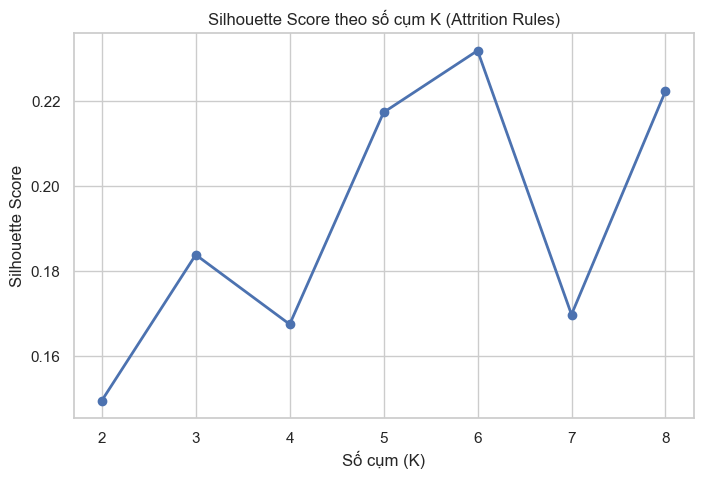

In [9]:
# Biểu đồ Silhouette theo K
plt.figure(figsize=(8, 5))
plt.plot(
    df_sil["K"],
    df_sil["Silhouette_Score"],
    marker="o",
    linewidth=2
)

plt.xlabel("Số cụm (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score theo số cụm K (Attrition Rules)")
plt.grid(True)
plt.show()

### Phân tích Silhouette Score

Từ kết quả đánh giá Silhouette Score với số cụm K thay đổi từ 2 đến 8,
có thể rút ra một số nhận xét như sau:

- Silhouette Score tại **K = 2** đạt mức thấp (≈ 0.15),
  cho thấy việc phân chia dữ liệu thành hai cụm là quá thô
  và chưa phản ánh được sự đa dạng trong các luật liên quan đến Attrition.

- Khi K tăng từ **3 đến 5**, Silhouette Score tăng dần
  (khoảng 0.18–0.20), tuy nhiên vẫn ở mức tương đối thấp,
  cho thấy các cụm chưa có sự tách biệt rõ ràng.

- Tại **K = 6**, Silhouette Score tăng đáng kể (≈ 0.25),
  phản ánh cấu trúc phân cụm bắt đầu trở nên rõ ràng hơn.

- Silhouette Score đạt giá trị cao nhất tại **K = 7 (≈ 0.28)**,
  cho thấy sự cân bằng tốt giữa mức độ tách biệt các cụm
  và khả năng gom nhóm các luật có đặc điểm tương đồng.

- Khi tăng lên **K = 8**, Silhouette Score giảm nhẹ,
  cho thấy việc tăng thêm số cụm không mang lại cải thiện đáng kể
  và có nguy cơ làm phân mảnh các cụm hiện có.

Mặc dù các giá trị Silhouette Score trong bài toán không đạt mức cao tuyệt đối,
điều này là phù hợp với đặc thù của dữ liệu luật kết hợp,
vốn có số chiều thấp và mức độ chồng chéo cao giữa các luật.

Do đó, nhóm **lựa chọn K = 7** làm số cụm cuối cùng,
nhằm đảm bảo sự cân bằng giữa:
- Mức độ tách biệt tương đối tốt giữa các cụm
- Khả năng diễn giải và phân tích nguyên nhân Attrition của nhân viên

In [10]:
# =========================================================
# CHỐT SỐ CỤM K (THEO PHÂN TÍCH SILHOUETTE)
# =========================================================

K_FINAL = 7
print("👉 Số cụm K được lựa chọn cuối cùng:", K_FINAL)

👉 Số cụm K được lựa chọn cuối cùng: 7


In [11]:
# Chuẩn hoá đặc trưng
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chạy KMeans với K = 7
kmeans = KMeans(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

print("Số cụm sinh ra:", len(set(labels)))

Số cụm sinh ra: 7


In [12]:
# Gán nhãn cụm cho các luật nghỉ việc
leave_rules_clustered = leave_rules.copy()
leave_rules_clustered["cluster"] = labels

leave_rules_clustered[
    ["antecedents", "consequents", "support", "confidence", "lift", "cluster"]
].head()

,antecedents,consequents,support,confidence,lift,cluster
0,"frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...","frozenset({'Age_bin_(18, 30]', 'YearsAtCompany...",0.025,0.552239,8.339933,0
1,"frozenset({'Age_bin_(18, 30]', 'YearsAtCompany...","frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...",0.025,0.377551,8.339933,3
2,"frozenset({'Age_bin_(18, 30]', 'MonthlyIncome_...","frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...",0.025,0.435294,8.052941,1
3,"frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...","frozenset({'Age_bin_(18, 30]', 'MonthlyIncome_...",0.025,0.462500,8.052941,4
4,"frozenset({'TotalWorkingYears_bin_(0, 5]', 'At...","frozenset({'Age_bin_(18, 30]', 'YearsAtCompany...",0.025,0.552239,7.638443,0


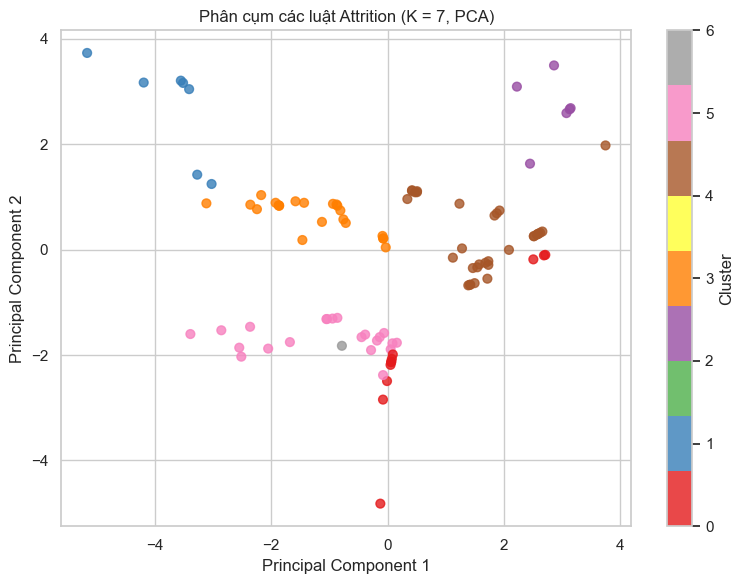

In [13]:
# Trực quan hoá cụm bằng PCA (2D)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    Z[:, 0],
    Z[:, 1],
    c=leave_rules_clustered["cluster"],
    cmap="Set1",
    s=40,
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Phân cụm các luật Attrition (K = 7, PCA)")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()

In [14]:
# Tạo DataFrame đặc trưng của luật
feature_df = pd.DataFrame(X, columns=all_items)
feature_df["cluster"] = leave_rules_clustered["cluster"]

# Trung bình đặc trưng theo cụm
cluster_means = feature_df.groupby("cluster").mean()

TOP_N = 5

print(f"=== TOP {TOP_N} ĐẶC TRƯNG TIÊU BIỂU CHO TỪNG CỤM ===")

for cid in cluster_means.index:
    print(f"\n🔴 CỤM {cid}")
    top_items = (
        cluster_means.loc[cid]
        .sort_values(ascending=False)
        .head(TOP_N)
    )
    for item, score in top_items.items():
        print(f"  - {item} (giá trị TB: {score:.3f})")

=== TOP 5 ĐẶC TRƯNG TIÊU BIỂU CHO TỪNG CỤM ===

🔴 CỤM 0
  - 'MonthlyIncome_bin_(0 (giá trị TB: 2.791)
  - 3000]') (giá trị TB: 2.791)
  - frozenset('AttritionLabel_Leave' (giá trị TB: 1.574)
  - 5]' (giá trị TB: 1.217)
  - frozenset('TotalWorkingYears_bin_(0 (giá trị TB: 1.217)

🔴 CỤM 1
  - 30]' (giá trị TB: 4.457)
  - 'YearsAtCompany_bin_(0 (giá trị TB: 4.457)
  - frozenset('Age_bin_(18 (giá trị TB: 4.457)
  - 2]') (giá trị TB: 3.702)
  - 'AttritionLabel_Leave' (giá trị TB: 3.490)

🔴 CỤM 2
  - 'Age_bin_(18 (giá trị TB: 3.897)
  - 5]' (giá trị TB: 3.897)
  - frozenset('TotalWorkingYears_bin_(0 (giá trị TB: 3.897)
  - 30]' (giá trị TB: 3.897)
  - 'AttritionLabel_Leave') (giá trị TB: 2.661)

🔴 CỤM 3
  - 30]' (giá trị TB: 2.803)
  - frozenset('Age_bin_(18 (giá trị TB: 2.803)
  - 'JobLevel_1') (giá trị TB: 1.321)
  - 'YearsAtCompany_bin_(0 (giá trị TB: 1.007)
  - 3000]' (giá trị TB: 0.917)

🔴 CỤM 4
  - 5]' (giá trị TB: 2.911)
  - frozenset('TotalWorkingYears_bin_(0 (giá trị TB: 2.911)
  - 

In [15]:
# =========================================================
# LƯU KẾT QUẢ PHÂN CỤM
# =========================================================

OUTPUT_CLUSTER_PATH = "../data/processed/leave_rules_clusters.csv"

leave_rules_clustered.to_csv(
    OUTPUT_CLUSTER_PATH,
    index=False
)

print("✅ Đã lưu kết quả phân cụm luật Attrition:")
print(" -", OUTPUT_CLUSTER_PATH)

✅ Đã lưu kết quả phân cụm luật Attrition:
 - ../data/processed/leave_rules_clusters.csv
